In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/somukavyasri/protein2/uniprotkb_reviewed_true_AND_NOT_databas_2026_02_25.fasta
/kaggle/input/datasets/somukavyasri/proteindata/pdb_data_seq.csv


In [2]:
pip install BIO

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.3/321.3 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 106.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# DATA PREPROCESSING

In [5]:
df = pd.read_csv('/kaggle/input/datasets/somukavyasri/proteindata/pdb_data_seq.csv')

# Keep only proteins
df = df[df['macromoleculeType'] == 'Protein']

# Remove duplicates
df = df.drop_duplicates(subset='sequence')

# Remove short sequences
df = df[df['sequence'].str.len() > 50]

print("Protein sequences:", df.shape)

Protein sequences: (80489, 5)


In [6]:
df_pos = df[['sequence']].copy()
df_pos['label'] = 1

print(df_pos.head())


                                             sequence  label
4   MVLSEGEWQLVLHVWAKVEADVAGHGQDILIRLFKSHPETLEKFDR...      1
7   MNIFEMLRIDEGLRLKIYKDTEGYYTIGIGHLLTKSPSLNAAAKSE...      1
8   MVLSEGEWQLVLHVWAKVEADVAGHGQDILIRLFKSHPETLEKFDR...      1
11  MNIFEMLRIDEGLRLKIYKDTEGYYTIGIGHLLTKSPSLNSLDAAK...      1
15  MNIFEMLRIDEGLRLKIYKDTEGYYTIGIGHLLTKSPSLNAAKSAA...      1


In [7]:
df_pos = df_pos.sample(n=50000, random_state=42)
df_pos.head()
print(df_pos.shape)

(50000, 2)


In [8]:
from Bio import SeqIO
import pandas as pd

sequences = []

for record in SeqIO.parse(
    '/kaggle/input/datasets/somukavyasri/protein2/uniprotkb_reviewed_true_AND_NOT_databas_2026_02_25.fasta',
    'fasta'
):
    sequences.append(str(record.seq))

df_neg = pd.DataFrame({'sequence': sequences})

print("Total sequences:", len(df_neg))

Total sequences: 519005


In [9]:
# Remove short sequences
df_neg = df_neg[df_neg['sequence'].str.len() > 50]

# Remove very long sequences (recommended)
df_neg = df_neg[df_neg['sequence'].str.len() < 1500]

print("After filtering:", len(df_neg))

After filtering: 518763


In [10]:
df_neg = df_neg[~df_neg['sequence'].isin(df_pos['sequence'])]

print("After removing overlap:", len(df_neg))

After removing overlap: 515674


In [11]:
df_neg = df_neg.sample(n=50000, random_state=42)
df_neg['label'] = 0

print("Negatives:", df_neg.shape)
df_neg.head()

Negatives: (50000, 2)


,sequence,label
316806,MKASELTAKSVEELNAELLGLLREQFNLRMQHATGQLTQTHQLKIV...,0
258871,MDKIEVRGARTHNLKNINLVIPRDKLIVVTGLSGSGKSSLAFDTLY...,0
278992,MRDYIPKYLNAFLLAFATFAVGFAIFIAKDSNSSSHLYFSTSSSLW...,0
256757,MQDVKKRVEKLHDLLNQYSYEYYVQDNPSVPDSEYDKLLHELIEIE...,0
410373,MNCEDQAVDLCKAIDLCNVSDNTISHPTPAEEILPRDGLQLMDGDQ...,0


In [12]:
df_final = pd.concat([df_pos, df_neg])
df_final = df_final.sample(frac=1, random_state=42).reset_index(drop=True)

print(df_final['label'].value_counts())

label
0    50000
1    50000
Name: count, dtype: int64


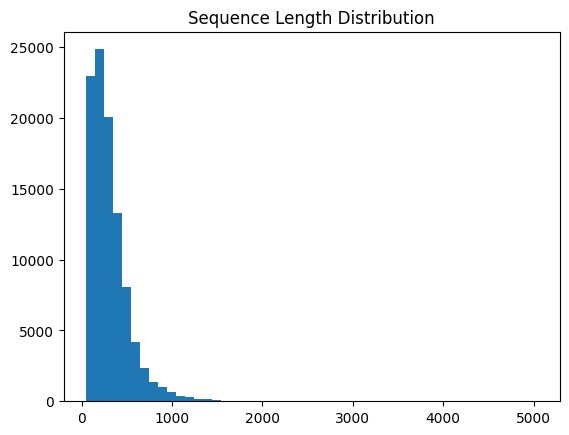

In [13]:
df_final['length'] = df_final['sequence'].str.len()

plt.hist(df_final['length'], bins=50)
plt.title("Sequence Length Distribution")
plt.show()

In [14]:
from sklearn.model_selection import train_test_split

X = df_final['sequence']
y = df_final['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("training_size:",len(X_train),"train_size", len(X_test))

training_size: 80000 train_size 20000


In [15]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(char_level=True)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

max_len = 600

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

2026-03-05 05:14:47.566463: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772687687.793965      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772687687.852191      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772687688.337415      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772687688.337485      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772687688.337488      24 computation_placer.cc:177] computation placer alr

In [16]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, GlobalMaxPooling1D
from tensorflow.keras.layers import Dense, Dropout

cnn_model = Sequential([
    Embedding(input_dim=len(tokenizer.word_index)+1,
              output_dim=64,
              input_length=max_len),

    Conv1D(128, 5, activation='relu'),
    MaxPooling1D(2),

    Conv1D(64, 3, activation='relu'),
    GlobalMaxPooling1D(),

    Dense(64, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

cnn_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1772687716.314716      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772687716.320512      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# CNN MODEL

In [17]:
history_cnn = cnn_model.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=8,
    batch_size=64
)

Epoch 1/8


I0000 00:00:1772687718.298573      82 service.cc:152] XLA service 0x7cd2940061f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772687718.298627      82 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1772687718.298634      82 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1772687718.828341      82 cuda_dnn.cc:529] Loaded cuDNN version 91002


  17/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.4538 - loss: 0.6970 

I0000 00:00:1772687721.971922      82 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1000/1000 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.6399 - loss: 0.6048 - val_accuracy: 0.7421 - val_loss: 0.5069
Epoch 2/8
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.7447 - loss: 0.5071 - val_accuracy: 0.7669 - val_loss: 0.4732
Epoch 3/8
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.7760 - loss: 0.4612 - val_accuracy: 0.7856 - val_loss: 0.4422
Epoch 4/8
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.8022 - loss: 0.4224 - val_accuracy: 0.7953 - val_loss: 0.4298
Epoch 5/8
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.8294 - loss: 0.3800 - val_accuracy: 0.8175 - val_loss: 0.4056
Epoch 6/8
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.8429 - loss: 0.3545 - val_accuracy: 0.8184 - val_loss: 0.4064
Epoch 7/8
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.8592 - loss: 0.3287 - val_accuracy: 0.8264 - val_loss: 0.3989
Epoch 8/8
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.8644 - loss: 0.3144 - va

# CNN + BiLSTM

In [18]:
from tensorflow.keras.layers import LSTM, Bidirectional

bilstm_model = Sequential([
    Embedding(input_dim=len(tokenizer.word_index)+1,
              output_dim=64,
              input_length=max_len),

    Conv1D(128, 5, activation='relu'),
    MaxPooling1D(2),

    Bidirectional(LSTM(64)),

    Dense(64, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

bilstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

bilstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
history_bilstm = bilstm_model.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=8,
    batch_size=64
)

Epoch 1/8
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 35s 30ms/step - accuracy: 0.7800 - loss: 0.4569 - val_accuracy: 0.8341 - val_loss: 0.3764
Epoch 2/8
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 29s 29ms/step - accuracy: 0.8341 - loss: 0.3767 - val_accuracy: 0.8349 - val_loss: 0.3708
Epoch 3/8
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 30s 30ms/step - accuracy: 0.8391 - loss: 0.3643 - val_accuracy: 0.8698 - val_loss: 0.3211
Epoch 4/8
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 30s 30ms/step - accuracy: 0.8698 - loss: 0.3156 - val_accuracy: 0.8754 - val_loss: 0.2995
Epoch 5/8
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 30s 30ms/step - accuracy: 0.8781 - loss: 0.2942 - val_accuracy: 0.8762 - val_loss: 0.2968
Epoch 6/8
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 30s 30ms/step - accuracy: 0.8843 - loss: 0.2783 - val_accuracy: 0.8789 - val_loss: 0.2973
Epoch 7/8
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 30s 30ms/step - accuracy: 0.8941 - loss: 0.2625 - val_accuracy: 0.8787 - val_loss: 0.3034
Epoch 8/8
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 30s 30ms/step - accuracy: 0.8998 - loss: 0

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, roc_auc_score

def evaluate_model(model, X_test, y_test):
    y_pred_prob = model.predict(X_test)
    y_pred = (y_pred_prob > 0.5).astype(int)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1:", f1_score(y_test, y_pred))
    print("MCC:", matthews_corrcoef(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_pred_prob))

In [21]:
print("CNN Results")
evaluate_model(cnn_model, X_test_pad, y_test)

print("CNN + BiLSTM Results")
evaluate_model(bilstm_model, X_test_pad, y_test)

CNN Results
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Accuracy: 0.82705
Precision: 0.8749283503381864
Recall: 0.7632
F1: 0.8152539657106233
MCC: 0.6594994271936522
ROC-AUC: 0.90060826
CNN + BiLSTM Results
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step
Accuracy: 0.88605
Precision: 0.9217742816562876
Recall: 0.8437
F1: 0.8810108077063645
MCC: 0.774884548887141
ROC-AUC: 0.943016365


# Evaluation


In [22]:
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# CNN predictions
cnn_prob = cnn_model.predict(X_test_pad)
cnn_pred = (cnn_prob > 0.5).astype(int)

# BiLSTM predictions
bilstm_prob = bilstm_model.predict(X_test_pad)
bilstm_pred = (bilstm_prob > 0.5).astype(int)

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step


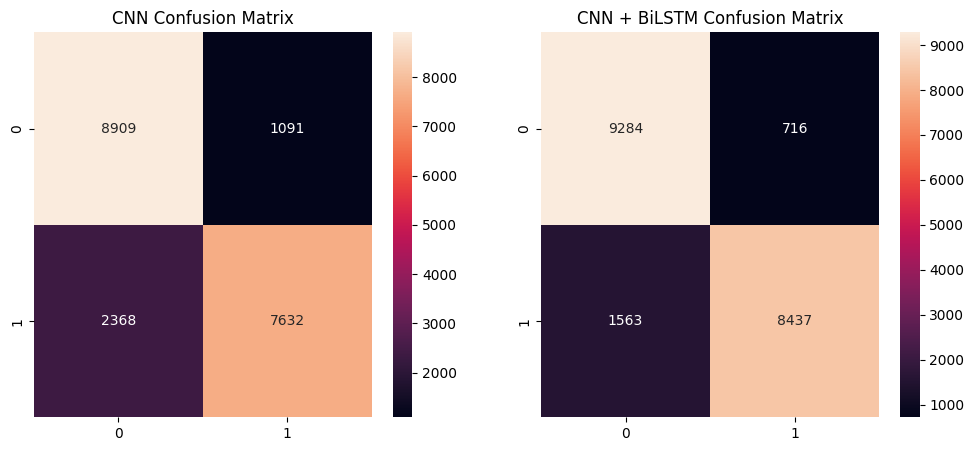

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm1 = confusion_matrix(y_test, cnn_pred)
sns.heatmap(cm1, annot=True, fmt='d', ax=axes[0])
axes[0].set_title("CNN Confusion Matrix")

cm2 = confusion_matrix(y_test, bilstm_pred)
sns.heatmap(cm2, annot=True, fmt='d', ax=axes[1])
axes[1].set_title("CNN + BiLSTM Confusion Matrix")

plt.show()

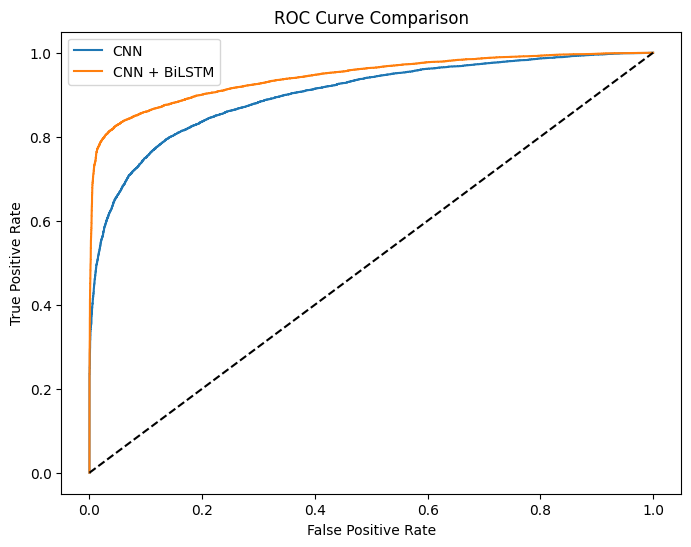

In [24]:
fpr1, tpr1, _ = roc_curve(y_test, cnn_prob)
fpr2, tpr2, _ = roc_curve(y_test, bilstm_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr1, tpr1, label="CNN")
plt.plot(fpr2, tpr2, label="CNN + BiLSTM")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

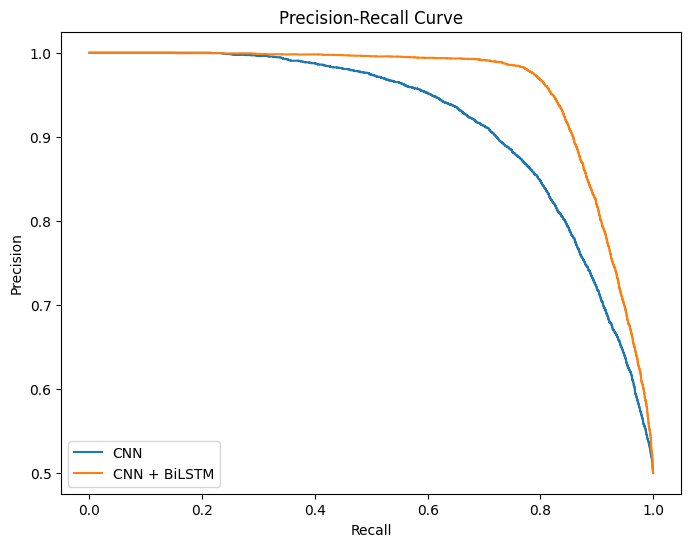

In [25]:
prec1, rec1, _ = precision_recall_curve(y_test, cnn_prob)
prec2, rec2, _ = precision_recall_curve(y_test, bilstm_prob)

plt.figure(figsize=(8,6))
plt.plot(rec1, prec1, label="CNN")
plt.plot(rec2, prec2, label="CNN + BiLSTM")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

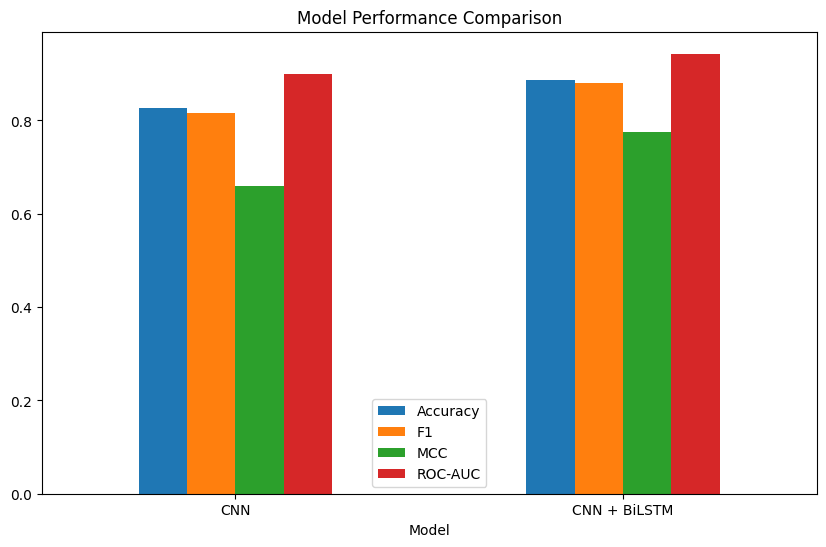

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, roc_auc_score

metrics = {
    "Model": ["CNN", "CNN + BiLSTM"],
    "Accuracy": [
        accuracy_score(y_test, cnn_pred),
        accuracy_score(y_test, bilstm_pred)
    ],
    "F1": [
        f1_score(y_test, cnn_pred),
        f1_score(y_test, bilstm_pred)
    ],
    "MCC": [
        matthews_corrcoef(y_test, cnn_pred),
        matthews_corrcoef(y_test, bilstm_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, cnn_prob),
        roc_auc_score(y_test, bilstm_prob)
    ]
}

import pandas as pd
metrics_df = pd.DataFrame(metrics)

metrics_df.set_index("Model").plot(kind="bar", figsize=(10,6))
plt.title("Model Performance Comparison")
plt.xticks(rotation=0)
plt.show()

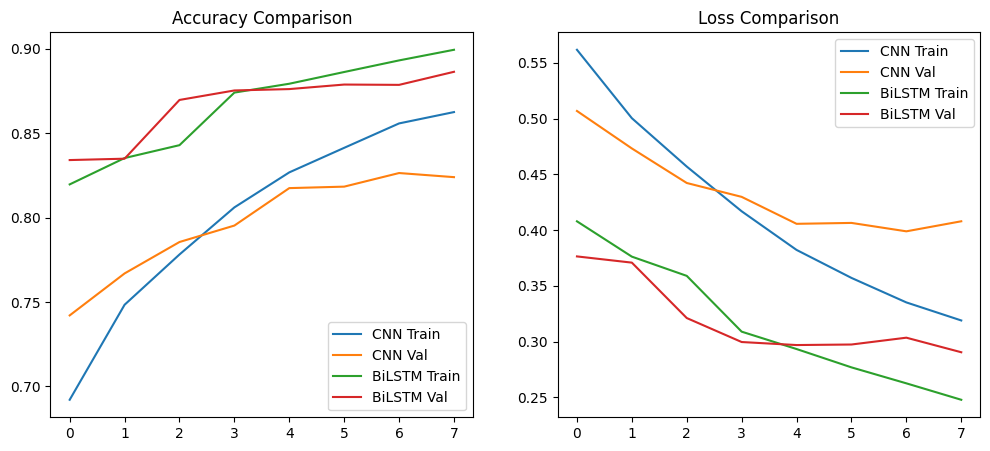

In [27]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_cnn.history['accuracy'], label="CNN Train")
plt.plot(history_cnn.history['val_accuracy'], label="CNN Val")
plt.plot(history_bilstm.history['accuracy'], label="BiLSTM Train")
plt.plot(history_bilstm.history['val_accuracy'], label="BiLSTM Val")
plt.title("Accuracy Comparison")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_cnn.history['loss'], label="CNN Train")
plt.plot(history_cnn.history['val_loss'], label="CNN Val")
plt.plot(history_bilstm.history['loss'], label="BiLSTM Train")
plt.plot(history_bilstm.history['val_loss'], label="BiLSTM Val")
plt.title("Loss Comparison")
plt.legend()

plt.show()

In [28]:
def predict_sequence(model, sequence, tokenizer, max_len=600):
    
    sequence = sequence.upper().strip()
    
    # Encode
    seq_encoded = tokenizer.texts_to_sequences([sequence])
    seq_pad = pad_sequences(seq_encoded, maxlen=max_len,
                            padding='post', truncating='post')
    
    # Predict
    prob = float(model.predict(seq_pad)[0][0])
    label = 1 if prob > 0.5 else 0
    
    # Confidence logic
    if prob > 0.8:
        confidence = "High Confidence"
    elif prob > 0.6:
        confidence = "Moderate Confidence"
    else:
        confidence = "Low Confidence"
    
    result = {
        "Probability": round(prob, 4),
        "Predicted_Label": label,
        "Confidence": confidence,
        "Interpretation": "Likely Crystallizable" if label == 1 
                          else "Likely Non-Crystallizable"
    }
    
    return result

In [29]:
test_seq = X_test.iloc[10]

result = predict_sequence(bilstm_model, test_seq, tokenizer)

print(result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step
{'Probability': 0.3898, 'Predicted_Label': 0, 'Confidence': 'Low Confidence', 'Interpretation': 'Likely Non-Crystallizable'}


In [30]:
bilstm_model.save("/kaggle/working/bilstm_model.h5")

# Model save

In [31]:
import pickle

with open("/kaggle/working/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [32]:
import os
os.listdir("/kaggle/working/")

['tokenizer.pkl', '__notebook__.ipynb', 'bilstm_model.h5']